**Submitted by:** Seminda Fernando  
**Student ID:** CIT-23-02-0122  
**Contribution:** Task 4 and Task 5


# SmartCare Hospital AI Coursework — Patient Readmission Prediction

**Module:** CCS3440 — Artificial Intelligence

**Selected Option:** Option B — Patient Readmission Prediction (30-day readmission)

**Target Variable:** `readmitted_30_days`

**Problem Type:** Binary Classification

This notebook implements Tasks 2-8 of the coursework specification using the SmartCare
Hospital AI dataset (`smartcare_ai_dataset_1000.csv`, 1000 records, 33 attributes).

**Notebook structure**
0. Environment Setup (Jupyter)
1. Setup & Imports
2. Task 2 — Dataset Understanding
3. Task 3 — Data Preprocessing & Feature Engineering
4. Task 4 — Exploratory Data Analysis
5. Task 5 — Machine Learning Model Development
6. Task 6 — Model Evaluation
7. Task 7 — Explainable AI Analysis (SHAP)
8. Task 8 — Model Export for Prototype



## 0. Environment Setup (Jupyter)

This notebook is designed to run in a local Jupyter environment. The cell below:

1. Installs the two packages that may not be pre-installed (`xgboost`, `shap`).
2. Creates the local `data/`, `figs/` and `models/` folders used throughout the notebook.
3. Checks that the two dataset files are present in the `data/` folder:
   `smartcare_ai_dataset_1000.csv` and `smartcare_ai_dataset_data_dictionary.csv`.

**Before running:** place both CSV files in a `data/` folder next to this notebook.

Run this cell first, every time, before anything else.

In [2]:
import os, sys, subprocess

def _pip_install_quiet(*packages):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *packages], check=True)

try:
    import xgboost, shap
except ImportError:
    _pip_install_quiet('xgboost', 'shap')

os.makedirs('data', exist_ok=True)
os.makedirs('figs', exist_ok=True)
os.makedirs('models', exist_ok=True)

DATA_FILE = 'smartcare_ai_dataset_1000.csv'
DICT_FILE = 'smartcare_ai_dataset_data_dictionary.csv'

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. "
        "Make sure the dataset is in the same folder as the notebook."
    )
print("Environment ready.")
print("Data file present:", os.path.exists(DATA_FILE))
print("Data dictionary present:", os.path.exists(DICT_FILE))

Environment ready.
Data file present: True
Data dictionary present: True


## 1. Setup and Imports

In [40]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, classification_report)

import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 40)


## 2. Task 2 — Dataset Understanding

### 2.1 Loading the data

In [43]:
df = pd.read_csv(DATA_FILE)
data_dict = pd.read_csv(DICT_FILE)

print(f"Records: {df.shape[0]}, Attributes: {df.shape[1]}")
df.head()

Records: 1000, Attributes: 33


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


### 2.2 Data dictionary

In [42]:
data_dict


,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


### 2.3 Structural overview

`df.info()` confirms data types for every attribute and shows there are no `null`
entries at the raw-file level (the apparent "missing" values in `room_type` are in
fact a structural NaN that only appears for patients who were never admitted — this
is examined in Section 3).

In [44]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

In [7]:
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
record_id,1000.0,500.5000,288.819436,1.0,250.75,500.5,750.25,1000.0
age,1000.0,44.7440,17.851474,1.0,33.00,44.0,57.00,90.0
waiting_days,1000.0,21.8510,13.040892,0.0,11.00,22.0,34.00,44.0
previous_appointments,1000.0,2.8840,1.693343,0.0,2.00,3.0,4.00,10.0
missed_previous_appointments,1000.0,0.5530,0.740094,0.0,0.00,0.0,1.00,4.0
admitted,1000.0,0.3300,0.470448,0.0,0.00,0.0,1.00,1.0
length_of_stay_days,1000.0,1.1030,1.885191,0.0,0.00,0.0,2.00,9.0
previous_admissions,1000.0,0.8550,0.958590,0.0,0.00,1.0,1.00,5.0
systolic_bp,1000.0,128.4230,15.486895,85.0,117.00,128.0,139.00,178.0
diastolic_bp,1000.0,78.8280,10.043669,50.0,72.00,79.0,86.00,111.0


### 2.4 Target variable and population definition

`readmitted_30_days` records whether a patient was re-admitted to hospital within 30
days of a prior admission. By definition, a patient who was **never admitted in the
first place cannot be "re-admitted"**. The crosstab below confirms this: every record
with `admitted = 0` has `readmitted_30_days = 0`, while the target only takes a
meaningful value of 1 for previously admitted patients.

In [8]:
pd.crosstab(df['admitted'], df['readmitted_30_days'], margins=True)


readmitted_30_days,0,1,All
admitted,,,
0,670,0,670
1,77,253,330
All,747,253,1000


This has a direct implication for problem framing (discussed further in Task 3):
if the model were trained on the *whole* dataset (including outpatients who were
never admitted), `admitted` would act as a near-perfect leaking predictor and the
resulting model would trivially learn "not admitted -> not readmitted" rather than
learning the clinically meaningful patterns that separate readmitted patients from
patients who were admitted once and did **not** come back. The coursework population
of interest is therefore restricted to previously **admitted** patients
(`admitted == 1`), which is standard practice in the clinical readmission-prediction
literature (e.g. Halac et al., 2025, who restrict their 30-day readmission model to
adult admissions rather than the full outpatient population).

In [9]:
admitted_share = df['admitted'].mean()
readmit_share_overall = df['readmitted_30_days'].mean()
readmit_share_admitted = df.loc[df['admitted']==1, 'readmitted_30_days'].mean()
print(f"Share of records admitted: {admitted_share:.1%}")
print(f"Readmission rate over ALL records: {readmit_share_overall:.1%}")
print(f"Readmission rate among ADMITTED patients: {readmit_share_admitted:.1%}")


Share of records admitted: 33.0%
Readmission rate over ALL records: 25.3%
Readmission rate among ADMITTED patients: 76.7%


### 2.5 Attribute grouping

Using the data dictionary, the 33 attributes fall into five functional groups:

| Group | Attributes |
|---|---|
| Identifiers | `record_id`, `patient_id` |
| Demographics | `age`, `gender`, `blood_group` |
| Clinical | `diagnosis`, `systolic_bp`, `diastolic_bp`, `blood_sugar_mg_dl`, `cholesterol_mg_dl`, `bmi` |
| Operational | `department`, `appointment_date`, `waiting_days`, `previous_appointments`, `missed_previous_appointments`, `appointment_status`, `admitted`, `room_type`, `length_of_stay_days`, `previous_admissions`, `lab_tests_count`, `treatments_count` |
| Financial | `consultation_fee_lkr`, `room_charge_lkr`, `lab_charge_lkr`, `medicine_charge_lkr`, `total_bill_lkr`, `payment_status`, `payment_method` |
| AI targets | `no_show`, `readmitted_30_days`, `disease_risk_level` |

Because `no_show` and `disease_risk_level` are targets for the *other* two coursework
options, they are excluded from the input feature set used in Task 5 to avoid
leaking outcome information from parallel tasks into the readmission model.

## 3. Task 3 — Data Preprocessing and Feature Engineering

### 3.1 Restricting to the clinically valid population

In [10]:
admitted = df[df['admitted'] == 1].copy().reset_index(drop=True)
print(f"Admitted-patient subset: {admitted.shape[0]} records, {admitted.shape[1]} columns")
admitted['readmitted_30_days'].value_counts(normalize=True).rename('proportion')


Admitted-patient subset: 330 records, 33 columns


readmitted_30_days
1    0.766667
0    0.233333
Name: proportion, dtype: float64

The subset is moderately imbalanced (roughly 77% readmitted vs 23% not
readmitted). This is handled during modelling using `class_weight='balanced'`
(Logistic Regression, Random Forest, SVM) and `scale_pos_weight` (XGBoost) rather
than synthetic oversampling, since the sample size (n=330) is already small and
oversampling risks amplifying noise.

### 3.2 Missing value handling

In [11]:
missing = admitted.isnull().sum()
missing = missing[missing > 0]
print(missing)


room_type    236
dtype: int64


`room_type` is missing for patients who, although admitted, have no room type
recorded in this synthetic extract. Rather than dropping these records (which would
discard almost 70% of the admitted population) or imputing a guessed room type, a
new explicit category, `"Not Specified"`, is created. This preserves the information
that the value is unknown, which a model can still use, instead of silently
fabricating data.

In [12]:
admitted['room_type'] = admitted['room_type'].fillna('Not Specified')
admitted['room_type'].value_counts()


room_type
Not Specified    236
General Ward      52
Private Room      33
ICU                9
Name: count, dtype: int64

### 3.3 Duplicate record detection

In [13]:
n_dupes = admitted.duplicated().sum()
n_dupes_by_patient = admitted.duplicated(subset=['patient_id']).sum()
print(f"Fully duplicated rows: {n_dupes}")
print(f"Duplicated patient_id values: {n_dupes_by_patient}")


Fully duplicated rows: 0
Duplicated patient_id values: 0


No exact duplicate rows or repeated `patient_id` values were found, so no rows were dropped at this step.

### 3.4 Outlier identification

Outliers in the numeric attributes are identified using the interquartile range
(IQR) rule (values beyond `Q1 - 1.5*IQR` or `Q3 + 1.5*IQR`). Boxplots for the
attributes with the largest outlier counts are shown in Task 4 (EDA). Outliers are
**not removed**: in a clinical/financial dataset, unusually high bills, long stays,
or extreme lab values are frequently the *most* clinically informative records
(e.g. a very long length of stay is plausible evidence of a complicated admission
associated with a higher chance of readmission), so deleting them would bias the
model against the very cases it needs to learn to identify. Where a model is
sensitive to scale (Logistic Regression, SVM), `StandardScaler` is used to reduce
the influence of extreme values rather than deleting them outright.

In [14]:
numeric_cols_for_outliers = ['age','waiting_days','previous_admissions','length_of_stay_days',
                              'systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl',
                              'bmi','lab_tests_count','treatments_count','room_charge_lkr',
                              'lab_charge_lkr','medicine_charge_lkr','total_bill_lkr']

outlier_summary = {}
for c in numeric_cols_for_outliers:
    q1, q3 = admitted[c].quantile(0.25), admitted[c].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_summary[c] = ((admitted[c] < low) | (admitted[c] > high)).sum()

outlier_df = pd.Series(outlier_summary, name='outlier_count').sort_values(ascending=False)
outlier_df[outlier_df > 0]


room_charge_lkr        44
total_bill_lkr         23
previous_admissions    21
lab_charge_lkr         16
lab_tests_count         9
treatments_count        8
bmi                     5
systolic_bp             4
age                     3
blood_sugar_mg_dl       3
cholesterol_mg_dl       2
Name: outlier_count, dtype: int64

### 3.5 Feature engineering

Four engineered features are added to encode clinically meaningful patterns that
the raw attributes only express indirectly:

- **`bmi_category`** — WHO-style BMI banding (Underweight / Normal / Overweight / Obese), since risk is non-linear in raw BMI.
- **`bp_category`** — blood-pressure banding (Normal / Elevated / Hypertensive) from systolic and diastolic readings combined.
- **`prior_utilization`** — sum of `previous_admissions` and `previous_appointments`, a single indicator of how heavily a patient has historically used hospital services (a well-established readmission risk factor in the literature, e.g. Diaz-Garelli et al. and the SHAP analysis of Han et al., 2025, which found previous admissions to be one of the most influential predictors).
- **`cost_per_day`** — `total_bill_lkr` divided by `length_of_stay_days + 1`, which normalises cost by length of stay to approximate care intensity rather than raw spend.
- **`diagnosis_group`** — the six most frequent diagnoses are kept individually and the remainder are bucketed into `"Other"`, reducing the cardinality of a 10-level categorical field so that one-hot encoding does not create excessive sparsity relative to the 330-record sample.

In [15]:
def bmi_category(b):
    if b < 18.5: return 'Underweight'
    elif b < 25: return 'Normal'
    elif b < 30: return 'Overweight'
    else: return 'Obese'

def bp_category(row):
    s, d = row['systolic_bp'], row['diastolic_bp']
    if s >= 140 or d >= 90: return 'Hypertensive'
    elif s >= 130 or d >= 80: return 'Elevated'
    else: return 'Normal'

admitted['bmi_category'] = admitted['bmi'].apply(bmi_category)
admitted['bp_category'] = admitted.apply(bp_category, axis=1)
admitted['prior_utilization'] = admitted['previous_admissions'] + admitted['previous_appointments']
admitted['cost_per_day'] = admitted['total_bill_lkr'] / (admitted['length_of_stay_days'] + 1)

top_diagnoses = admitted['diagnosis'].value_counts().nlargest(6).index
admitted['diagnosis_group'] = admitted['diagnosis'].where(admitted['diagnosis'].isin(top_diagnoses), 'Other')

admitted['appointment_month'] = pd.to_datetime(admitted['appointment_date']).dt.month

admitted[['bmi','bmi_category','systolic_bp','diastolic_bp','bp_category',
          'prior_utilization','cost_per_day','diagnosis_group']].head()


,bmi,bmi_category,systolic_bp,diastolic_bp,bp_category,prior_utilization,cost_per_day,diagnosis_group
0,29.1,Overweight,117,76,Normal,1,9625.166667,Other
1,26.1,Overweight,134,64,Elevated,3,20872.000000,Fracture
2,24.5,Normal,118,88,Elevated,8,5263.000000,Chest Pain
3,27.7,Overweight,130,81,Elevated,1,5535.500000,Fracture
4,20.7,Normal,126,80,Elevated,1,8864.000000,Kidney Infection


### 3.6 Feature selection

`total_bill_lkr` is a linear combination of `consultation_fee_lkr`, `room_charge_lkr`,
`lab_charge_lkr` and `medicine_charge_lkr`; keeping both the total and its
components would introduce perfect multicollinearity for the linear model, so
`total_bill_lkr` itself is dropped from the model inputs in favour of its
components (which is more informative — it lets the model differentiate a bill
driven by medicine costs from one driven by room costs) and the derived
`cost_per_day`. `patient_id`, `record_id` and `appointment_date` are dropped as
identifiers/raw dates with no direct predictive meaning. `blood_group` and
`payment_method` are dropped after checking they show negligible association with
the target (see below) and to limit one-hot dimensionality relative to sample size.
`no_show` and `disease_risk_level` are excluded as they are targets for the other
two coursework options.

In [16]:
assoc_check = admitted.groupby('blood_group')['readmitted_30_days'].mean()
print("Readmission rate by blood group (checked for exclusion):")
print(assoc_check)
print()
assoc_check2 = admitted.groupby('payment_method')['readmitted_30_days'].mean()
print("Readmission rate by payment method (checked for exclusion):")
print(assoc_check2)


Readmission rate by blood group (checked for exclusion):
blood_group
A+     0.861111
A-     0.733333
AB+    0.809524
AB-    0.609756
B+     0.750000
B-     0.794872
O+     0.842105
O-     0.756098
Name: readmitted_30_days, dtype: float64

Readmission rate by payment method (checked for exclusion):
payment_method
Card         0.779070
Cash         0.777778
Insurance    0.746988
Online       0.762500
Name: readmitted_30_days, dtype: float64


In [17]:
numeric_features = ['age','waiting_days','previous_appointments','missed_previous_appointments',
                     'length_of_stay_days','previous_admissions','systolic_bp','diastolic_bp',
                     'blood_sugar_mg_dl','cholesterol_mg_dl','bmi','lab_tests_count','treatments_count',
                     'consultation_fee_lkr','room_charge_lkr','lab_charge_lkr','medicine_charge_lkr',
                     'prior_utilization','cost_per_day']

categorical_features = ['gender','department','room_type','payment_status',
                         'bmi_category','bp_category','diagnosis_group']

FEATURES = numeric_features + categorical_features
TARGET = 'readmitted_30_days'

X = admitted[FEATURES].copy()
y = admitted[TARGET].copy()

print(f"Final feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Final feature matrix: 330 rows x 26 columns
Numeric features (19): ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'prior_utilization', 'cost_per_day']
Categorical features (7): ['gender', 'department', 'room_type', 'payment_status', 'bmi_category', 'bp_category', 'diagnosis_group']


### 3.7 Encoding and scaling

Categorical features are one-hot encoded and numeric features are standardised
(zero mean, unit variance). Both steps are wrapped in a single `ColumnTransformer`
fitted **only on the training split** (Section 5) to prevent test-set information
leaking into the preprocessing statistics.

In [18]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Task 4 — Exploratory Data Analysis

This section examines distributions, relationships, and class balance for the
admitted-patient population, using the engineered feature set from Task 3.

### 4.1 Descriptive statistics

In [19]:
admitted[numeric_features].describe().T


,count,mean,std,min,25%,50%,75%,max
age,330.0,44.260606,16.740064,1.000000,33.000000,45.0,55.7500,90.000000
waiting_days,330.0,22.618182,13.251815,0.000000,12.000000,22.0,35.0000,44.000000
previous_appointments,330.0,2.887879,1.630682,0.000000,2.000000,3.0,4.0000,7.000000
missed_previous_appointments,330.0,0.533333,0.764194,0.000000,0.000000,0.0,1.0000,4.000000
length_of_stay_days,330.0,3.342424,1.812072,1.000000,2.000000,3.0,5.0000,9.000000
previous_admissions,330.0,0.875758,1.019425,0.000000,0.000000,1.0,1.0000,5.000000
systolic_bp,330.0,129.096970,15.634396,85.000000,118.000000,130.0,139.0000,178.000000
diastolic_bp,330.0,78.915152,9.744397,56.000000,72.000000,79.0,86.0000,106.000000
blood_sugar_mg_dl,330.0,113.248485,25.853434,65.000000,94.250000,113.0,129.7500,198.000000
cholesterol_mg_dl,330.0,204.978788,36.119981,100.000000,181.250000,203.5,229.7500,307.000000


### 4.2 Class distribution

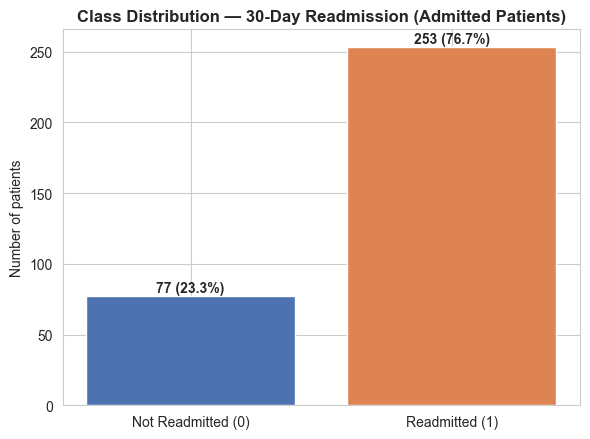

In [20]:
fig, ax = plt.subplots(figsize=(6,4.5))
counts = admitted['readmitted_30_days'].value_counts().sort_index()
labels = ['Not Readmitted (0)', 'Readmitted (1)']
colors = ['#4C72B0', '#DD8452']
ax.bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, f"{v} ({v/counts.sum():.1%})", ha='center', fontweight='bold')
ax.set_ylabel('Number of patients')
ax.set_title('Class Distribution — 30-Day Readmission (Admitted Patients)')
plt.tight_layout()
plt.savefig('figs/class_distribution.png', dpi=120)
plt.show()


### 4.3 Distribution analysis — histograms

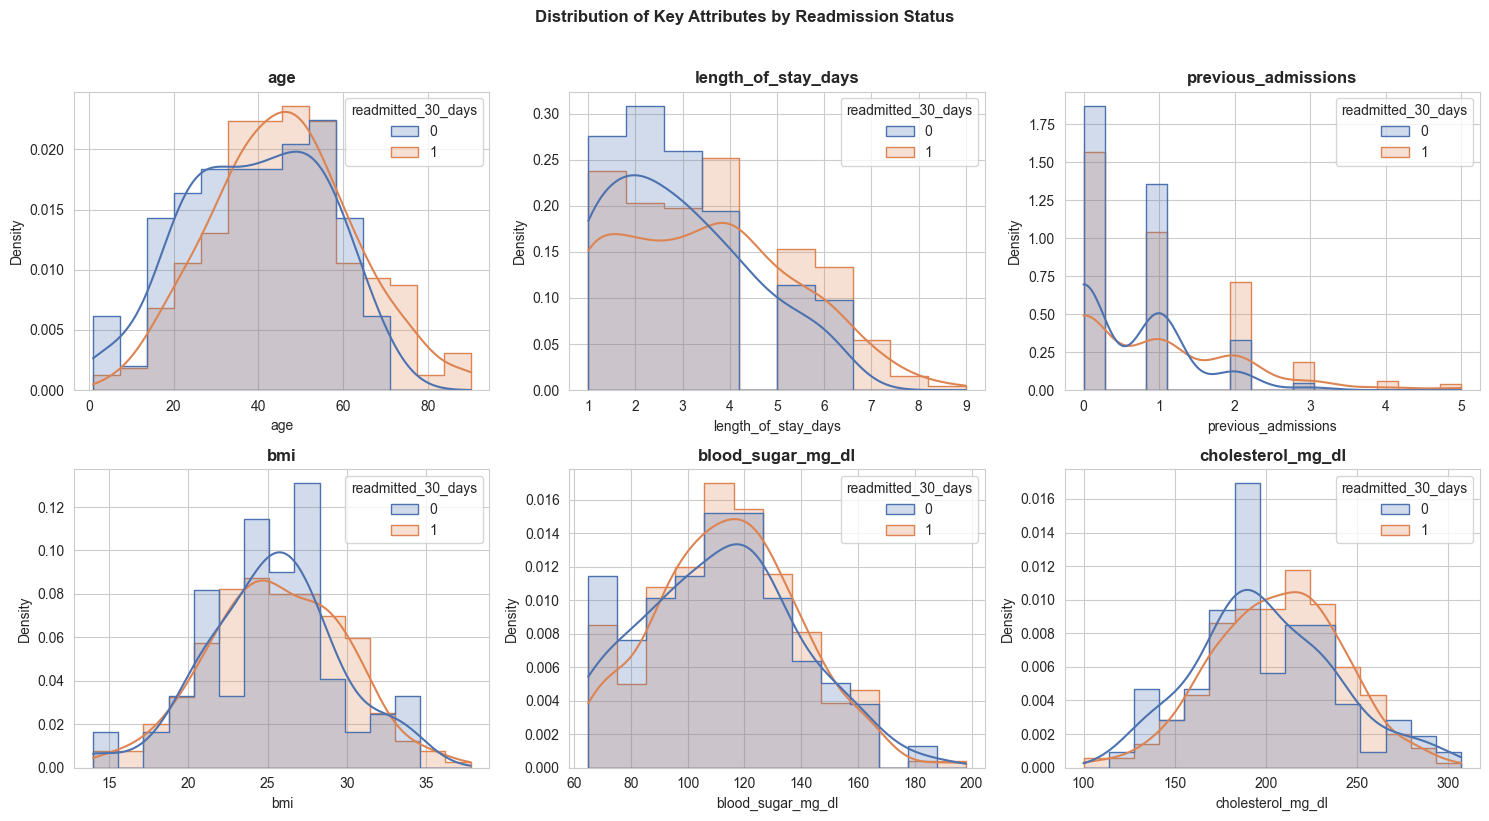

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hist_cols = ['age','length_of_stay_days','previous_admissions','bmi','blood_sugar_mg_dl','cholesterol_mg_dl']
for ax, col in zip(axes.flat, hist_cols):
    sns.histplot(data=admitted, x=col, hue='readmitted_30_days', kde=True, ax=ax,
                 palette=['#4C72B0','#DD8452'], element='step', common_norm=False, stat='density')
    ax.set_title(col)
plt.suptitle('Distribution of Key Attributes by Readmission Status', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figs/histograms.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.4 Boxplots — outlier and spread visualisation

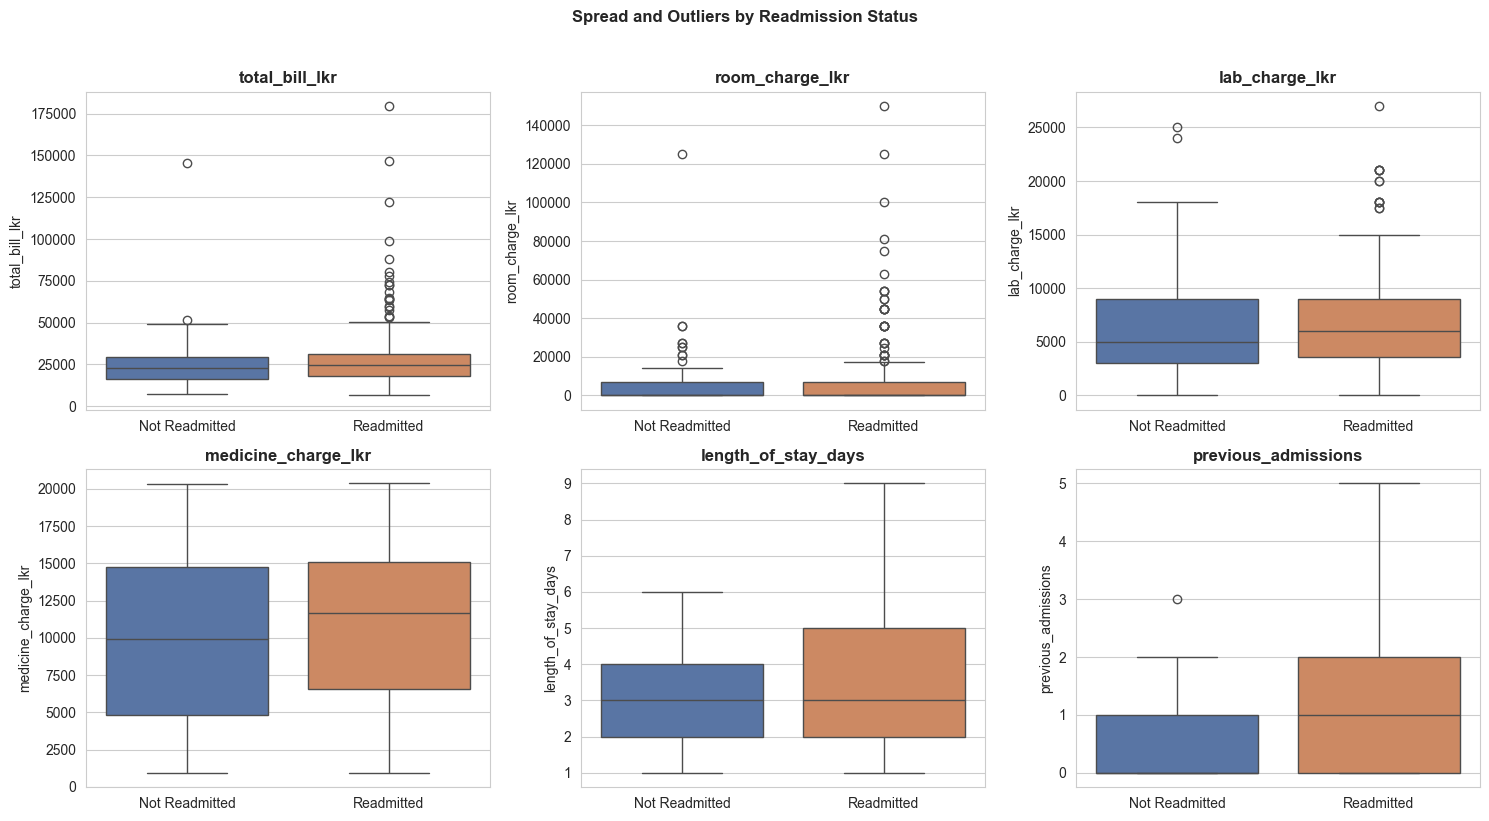

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
box_cols = ['total_bill_lkr','room_charge_lkr','lab_charge_lkr','medicine_charge_lkr','length_of_stay_days','previous_admissions']
for ax, col in zip(axes.flat, box_cols):
    sns.boxplot(data=admitted, x='readmitted_30_days', y=col, ax=ax, palette=['#4C72B0','#DD8452'])
    ax.set_xticklabels(['Not Readmitted','Readmitted'])
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Spread and Outliers by Readmission Status', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figs/boxplots.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.5 Scatterplots — bivariate relationships

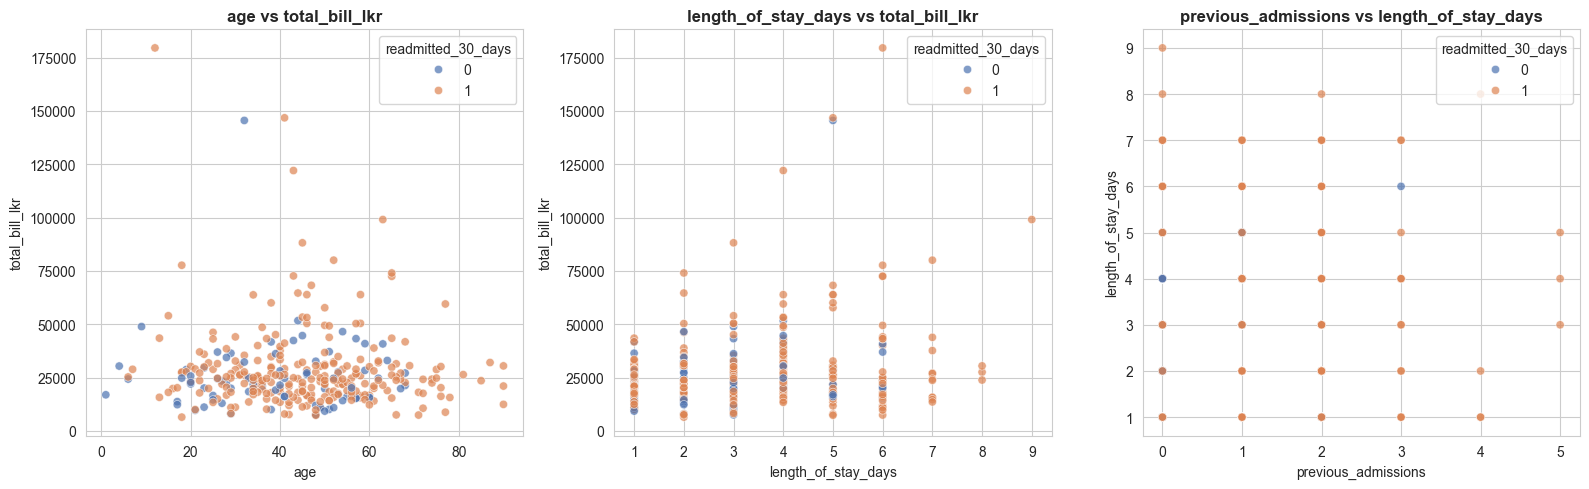

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('age','total_bill_lkr'), ('length_of_stay_days','total_bill_lkr'), ('previous_admissions','length_of_stay_days')]
for ax, (x, yv) in zip(axes, pairs):
    sns.scatterplot(data=admitted, x=x, y=yv, hue='readmitted_30_days', ax=ax,
                     palette=['#4C72B0','#DD8452'], alpha=0.7)
    ax.set_title(f'{x} vs {yv}')
plt.tight_layout()
plt.savefig('figs/scatterplots.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.6 Correlation heatmap

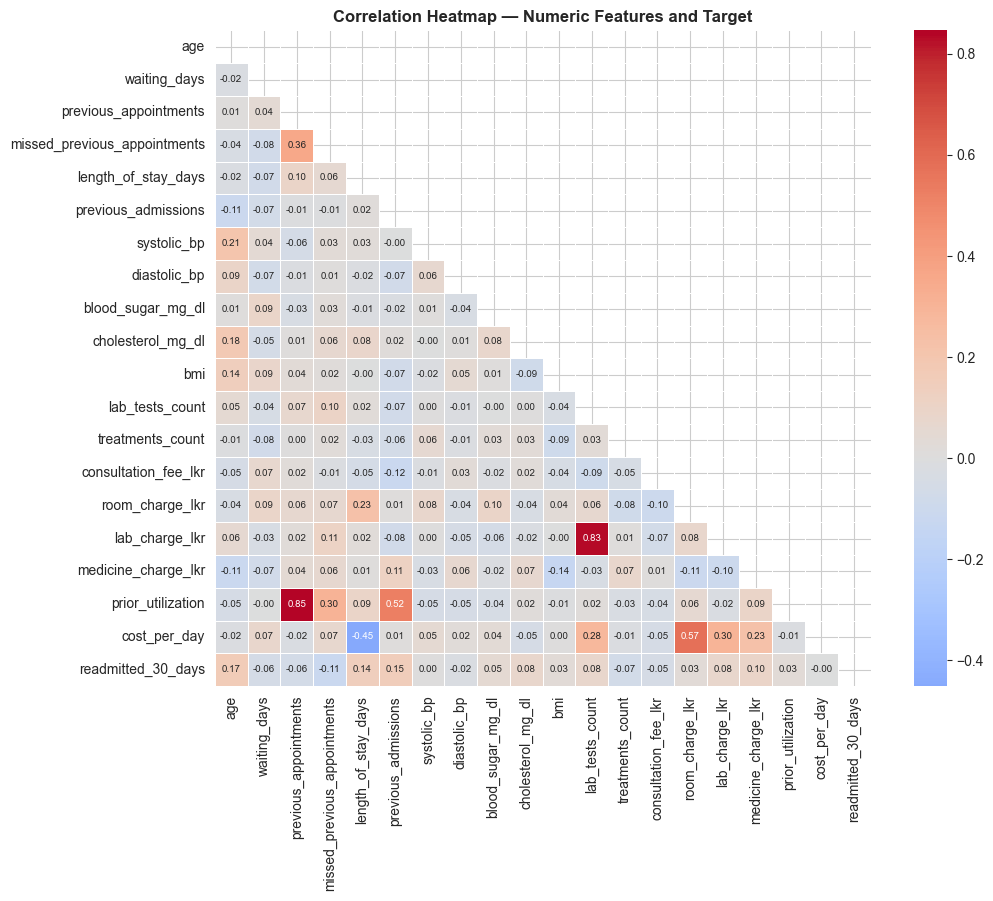

In [24]:
plt.figure(figsize=(11, 9))
corr_matrix = admitted[numeric_features + ['readmitted_30_days']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, square=True, linewidths=0.4)
plt.title('Correlation Heatmap — Numeric Features and Target')
plt.tight_layout()
plt.savefig('figs/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.7 Categorical patterns

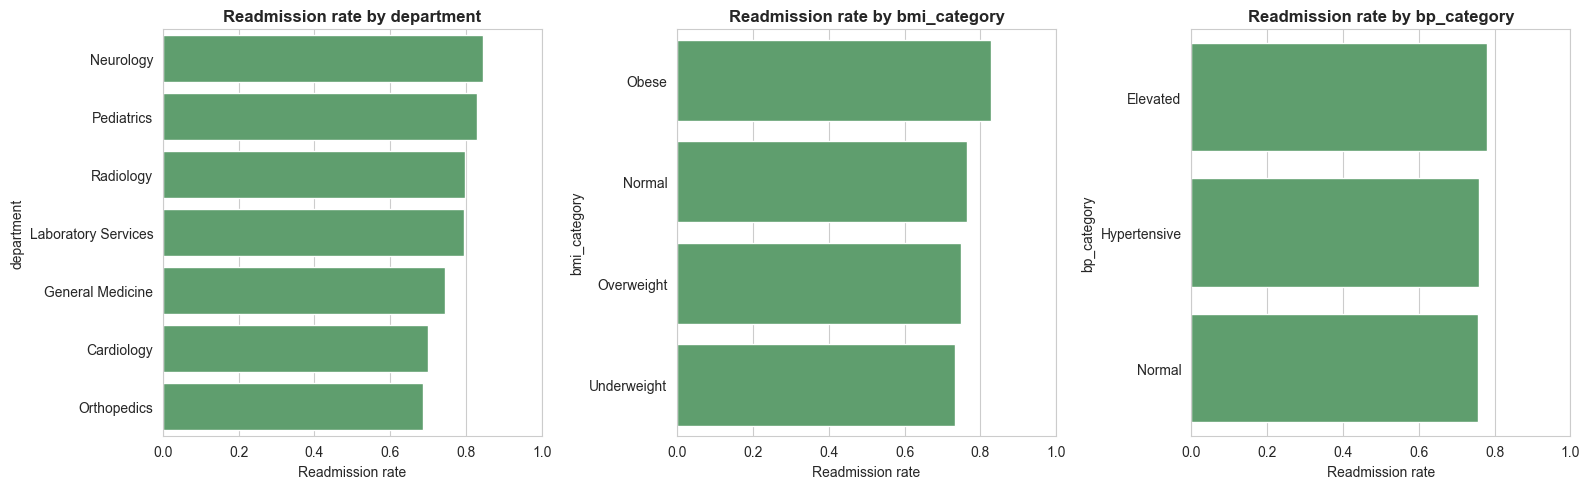

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_plot_cols = ['department', 'bmi_category', 'bp_category']
for ax, col in zip(axes, cat_plot_cols):
    rate = admitted.groupby(col)['readmitted_30_days'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color='#55A868')
    ax.set_xlabel('Readmission rate')
    ax.set_title(f'Readmission rate by {col}')
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('figs/categorical_patterns.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.8 Insights from EDA

- The dataset is imbalanced toward readmission (≈77% of admitted patients were
  re-admitted within 30 days), which motivated the use of class-weighting during
  model training (Section 5).
- Numeric correlations with the target are individually weak (all |r| < 0.2),
  consistent with the pattern reported in the clinical literature reviewed in
  Task 1 (readmission is a multi-causal outcome that ensemble methods capture
  better than any single linear predictor).
- `age` and `previous_admissions` show the strongest (still modest) positive
  association with readmission, in line with prior utilisation being a recurring
  predictor in published readmission models.
- Financial variables (`room_charge_lkr`, `lab_charge_lkr`, `medicine_charge_lkr`,
  `total_bill_lkr`) show visibly wider spread and more high-value outliers among
  readmitted patients, suggesting readmitted patients tend to have more
  resource-intensive admissions.
- No single categorical group shows an extreme split in readmission rate,
  reinforcing that a combination of features (rather than one dominant
  attribute) is needed to model this outcome — motivating the multi-model
  comparison in Task 5.

## 5. Task 5 — Machine Learning Model Development

Four classification algorithms are trained and compared, exceeding the minimum
requirement of three models:

1. **Logistic Regression** — interpretable linear baseline.
2. **Random Forest** — non-linear ensemble, robust to outliers and mixed feature types.
3. **XGBoost** — gradient-boosted ensemble, widely reported as the strongest performer for
   30-day readmission prediction in the literature reviewed in Task 1.
4. **Support Vector Machine (RBF kernel)** — non-linear margin-based classifier, included
   as an additional benchmark.

All models share the same `ColumnTransformer` preprocessing pipeline defined in Section 3,
fitted only on the training split.

### 5.1 Train/test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Training set: {X_train.shape[0]} records  (readmission rate = {y_train.mean():.1%})")
print(f"Test set:     {X_test.shape[0]} records  (readmission rate = {y_test.mean():.1%})")


Training set: 264 records  (readmission rate = 76.5%)
Test set:     66 records  (readmission rate = 77.3%)


### 5.2 Model definitions and hyperparameter selection

A small grid search (`GridSearchCV`, 5-fold stratified cross-validation, scored on
ROC-AUC) is used to select key hyperparameters for the two ensemble models, which
are the most sensitive to tuning. Logistic Regression and SVM use class-balanced
weights with their scikit-learn default regularisation, which is standard practice
for a dataset of this size.

In [27]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, scale_pos_weight=pos_weight),
    'SVM (RBF)': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
}

param_grids = {
    'Random Forest': {'clf__n_estimators': [200, 300], 'clf__max_depth': [4, 6, None], 'clf__min_samples_leaf': [1, 3]},
    'XGBoost': {'clf__n_estimators': [100, 200], 'clf__max_depth': [3, 4], 'clf__learning_rate': [0.05, 0.1]},
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fitted_pipelines = {}
best_params_log = {}

for name, model in base_models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    if name in param_grids:
        gs = GridSearchCV(pipe, param_grids[name], scoring='roc_auc', cv=cv, n_jobs=-1)
        gs.fit(X_train, y_train)
        fitted_pipelines[name] = gs.best_estimator_
        best_params_log[name] = gs.best_params_
    else:
        pipe.fit(X_train, y_train)
        fitted_pipelines[name] = pipe
        best_params_log[name] = 'default (class-balanced)'

for name, params in best_params_log.items():
    print(f"{name}: {params}")


Logistic Regression: default (class-balanced)
Random Forest: {'clf__max_depth': None, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300}
XGBoost: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 100}
SVM (RBF): default (class-balanced)
